In [7]:
library(ggplot2)
library(tidyverse)

data <- read.csv("liver_cancer_data.csv") 
age <- (data$age_years) 

mean(age)
median(age)
sd(age)
#?quantile 
cat('deciles', quantile(age, probs = c(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1)))
#?max
cat('\nmax age', max(age))
cat('\nmin age', min(age))



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] 60.65833

[1] 60

[1] 11.07385

deciles 46 50 55.7 58 60 63 66 70 76.1 86
max age 86
min age 34

In [57]:
data  %>% pull(tumor_size_mm) %>% quantile(probs = c(0.25, 0.5, 0.75, 1))

25%     50%     75%    100% 
 30.075  41.650  64.000 134.300

In [58]:
data  %>% head(5)

,sample_id,sex,age_years,disease_stage,tumor_size_mm,afp_ng_ml,marker_expression_au
,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>
1,LC_001,Male,54,Early,32.6,28.5,11.7
2,LC_002,Male,60,Early,30.9,49.1,7.4
3,LC_003,Female,50,Early,23.8,20.3,14.0
4,LC_004,Female,65,Early,39.8,12.7,18.6
5,LC_005,Female,63,Early,42.4,85.7,27.3


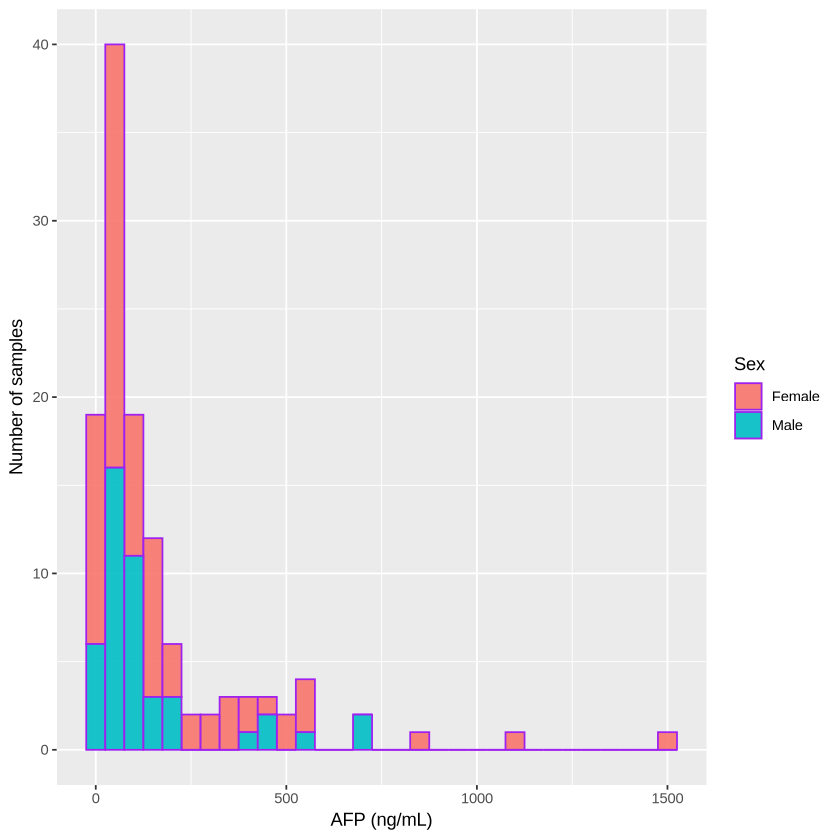

In [12]:
# HOW A GGPLOT GRAPH WORKS
#
# ggplot() starts a graph.
# data tells ggplot2 which table to use.
# aes() connects columns in the table to visual properties:
#   x and y define the axes;
#   fill controls the inside color;
#   color controls outlines or lines.
# geom_*() chooses what to draw: bars, curves, violins, or boxes.
# labs() changes the labels shown to the reader.
# The + sign adds another layer or setting to the graph.
#
# A value INSIDE aes(), such as fill = sex, depends on a data column.
# A value OUTSIDE aes(), such as fill = "purple", is the same for everything.


# HISTOGRAM: HOW DOES IT WORK?
#
# A histogram shows the distribution of one numerical variable.
# First, it divides the range of values into intervals called bins.
# Then, it counts how many observations fall into each bin.
#
# In this example, the x-axis shows AFP values, and the y-axis shows
# the number of samples in each AFP interval.
# binwidth = 50 means that each interval is 50 ng/mL wide.
#
# Because fill = sex is inside aes(), ggplot2 counts Female and Male
# samples separately. position = "stack" stacks their counts in each bar.
#
# Try changing binwidth. Do you see a different picture of the same data?

#?geom_histogram

ggplot() +
  geom_histogram(
    mapping = aes(x = afp_ng_ml, fill = sex), # Which variable to plot; fill maps groups to colors
    data = data,                 # Data used by this layer
    stat = "bin",                 # Divide values into bins and count observations
    position = "stack",           # Stack the bars for different groups
    binwidth = 50,                # Width of each bin in AFP units
    orientation = "x",            # The measured variable is on the x-axis
    lineend = "butt",             # Shape of line ends
    linejoin = "mitre",           # Shape of corners where lines meet
    na.rm = FALSE,               # Remove missing values and show a warning
    show.legend = TRUE,          # Display the legend for disease_stage
    color = "purple",             # bar border color
    alpha = 0.9                  #  bar transparency
  ) +
  labs(
    x = "AFP (ng/mL)",
    y = "Number of samples",
    fill = "Sex"
  )




In [ ]:
#Do the same with a different column:


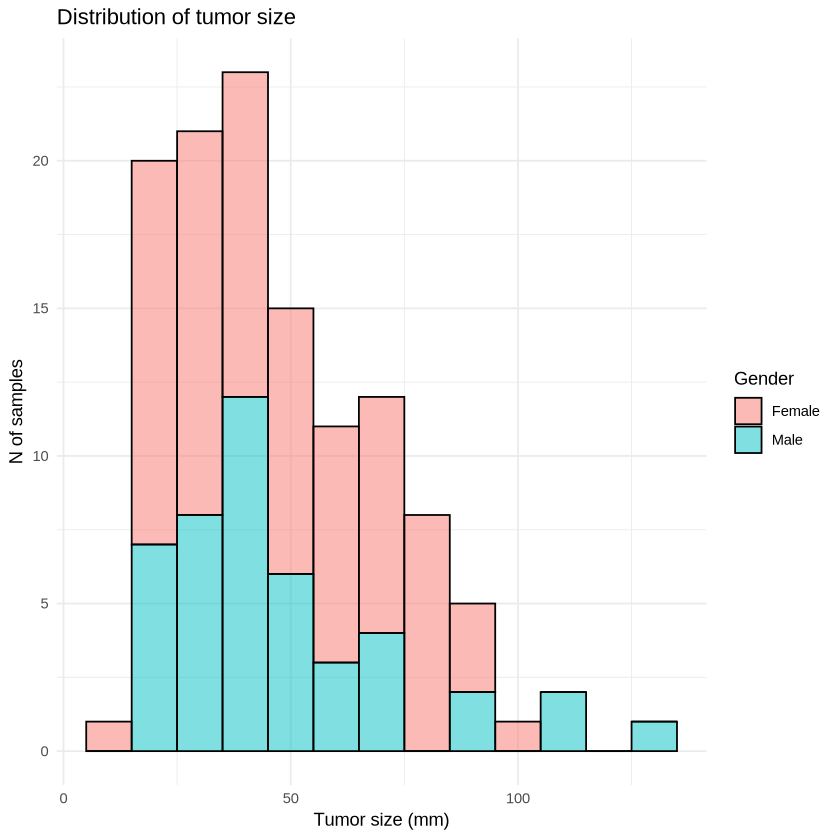

In [54]:
ggplot() + geom_histogram(data = data, aes(x =  tumor_size_mm, fill = sex),
                         stat = 'bin', binwidth = 10, orientation = 'x', linejoin = 'mitre', color = 'black', alpha = 0.5, show.legend = TRUE) +
labs(x = 'Tumor size (mm)', y = 'N of samples', fill = 'Gender', title = 'Distribution of tumor size') + theme_minimal()

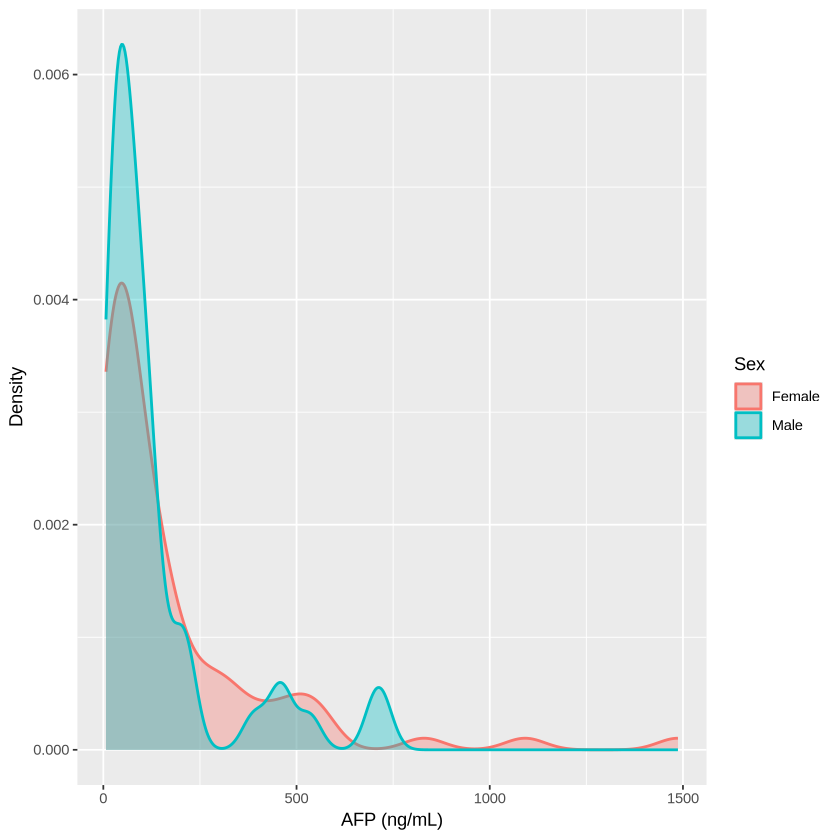

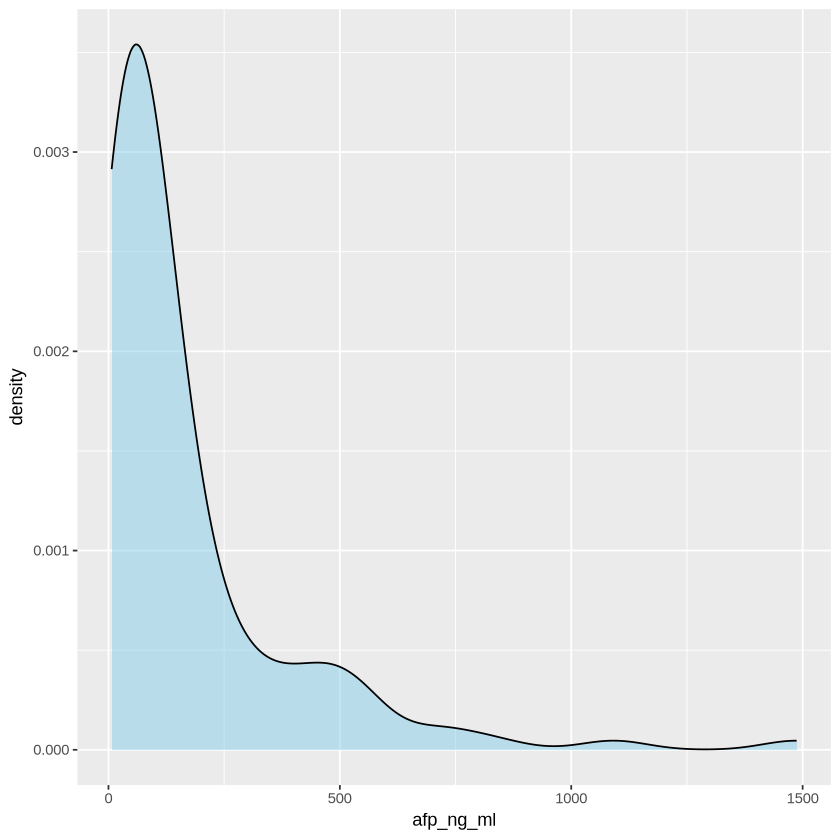

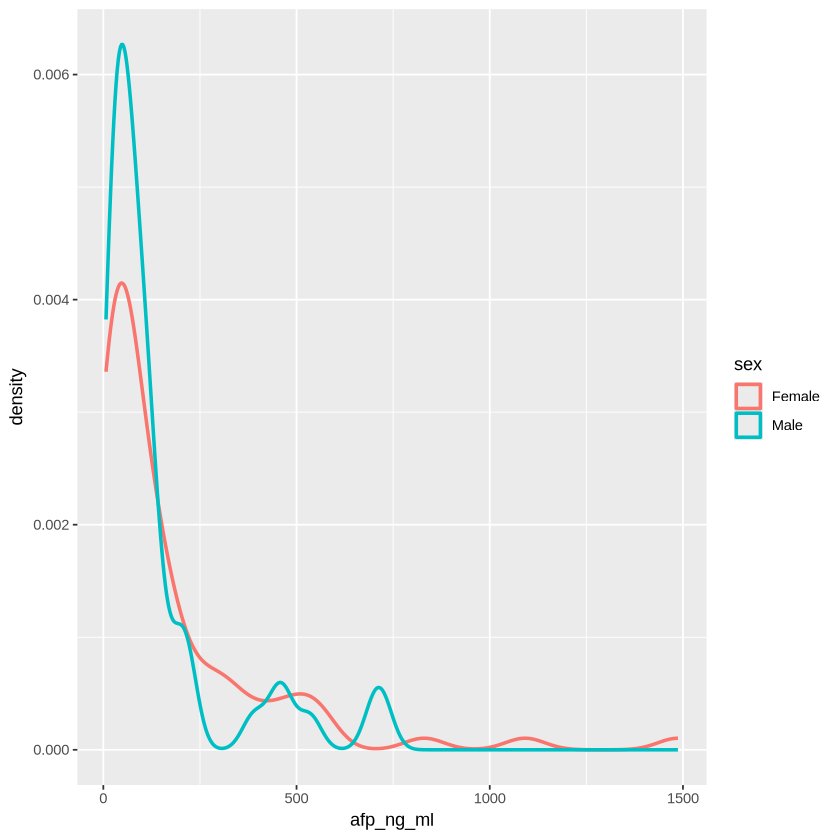

In [56]:
# DENSITY PLOT: HOW DOES IT WORK?
#
# A density plot shows a smoothed estimate of a numerical distribution.
# Imagine placing a small smooth curve over each observation and adding
# all those curves together. The result is one continuous curve.
#
# The x-axis shows AFP values. The y-axis shows estimated density,
# not the number of samples. The total area under each group's
# density curve is approximately 1.
#
# Because fill = sex and color = sex are inside aes(), ggplot2 draws
# one distribution for each sex. position = "identity" overlays them.
# alpha makes the filled areas transparent so both remain visible.
#
# adjust controls smoothing: smaller values show more detail;
# larger values produce smoother curves. Small bumps may be noise,
# so do not interpret every peak as a distinct biological group.

#?geom_density

ggplot() +
  geom_density(
    mapping = aes(x = afp_ng_ml, fill = sex, color = sex), # Plot AFP; use colors for sex groups
    data = data,                   # Data used by this layer
    stat = "density",             # Calculate a smoothed density estimate
    position = "identity",        # Draw the two distributions on top of each other
    outline.type = "upper",       # Draw the upper outline of each density shape
    lineend = "butt",             # Shape of the ends of outline lines
    linejoin = "round",           # Shape where outline segments meet
    linemitre = 10,              # Limit for sharp corners when using mitre joins
    na.rm = FALSE,               # Remove missing values with a warning
    show.legend = TRUE,          # Show the legend
    inherit.aes = TRUE,          # Also use mappings from ggplot(), if there are any
    adjust = 1,                  # Smoothing adjustment: smaller = more detail
    alpha = 0.35,                # Transparency of the filled areas
    linewidth = 0.8             # Width of the outline
  ) +
  labs(
    x = "AFP (ng/mL)",
    y = "Density",
    fill = "Sex",
    color = "Sex"
  )


# More smoothing: the curve becomes smoother.
ggplot(data, aes(x = afp_ng_ml)) +
  geom_density(adjust = 2, fill = "skyblue", alpha = 0.5)

# Use only one outline, without a filled area.
ggplot(data, aes(x = afp_ng_ml, color = sex)) +
  geom_density(fill = NA, linewidth = 1)






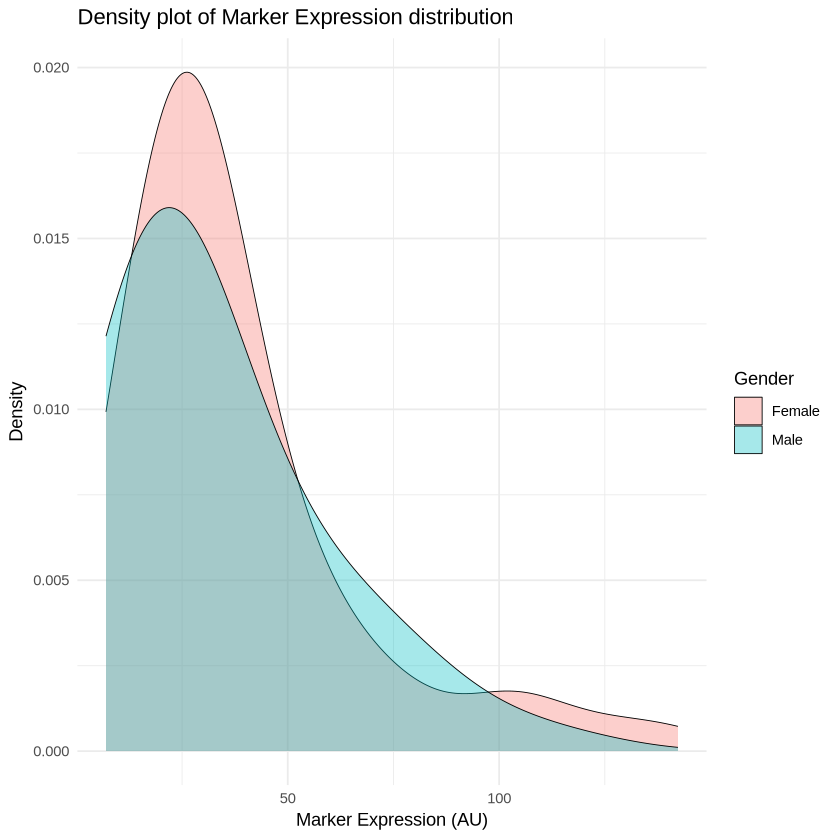

In [85]:
ggplot() + geom_density(data = data, aes(x = marker_expression_au, fill = as.factor(sex)),
                       alpha = 0.35, linewidth = 0.25, adjust = 2) + theme_minimal() + 
labs(y = 'Density', x = 'Marker Expression (AU)', fill = 'Gender', title = 'Density plot of Marker Expression distribution')

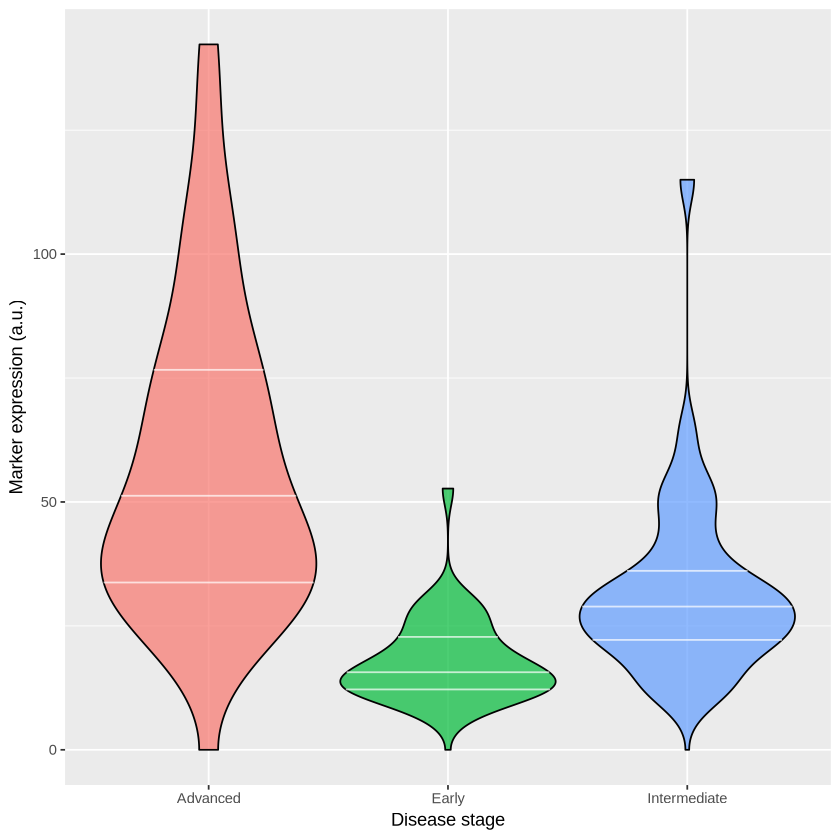

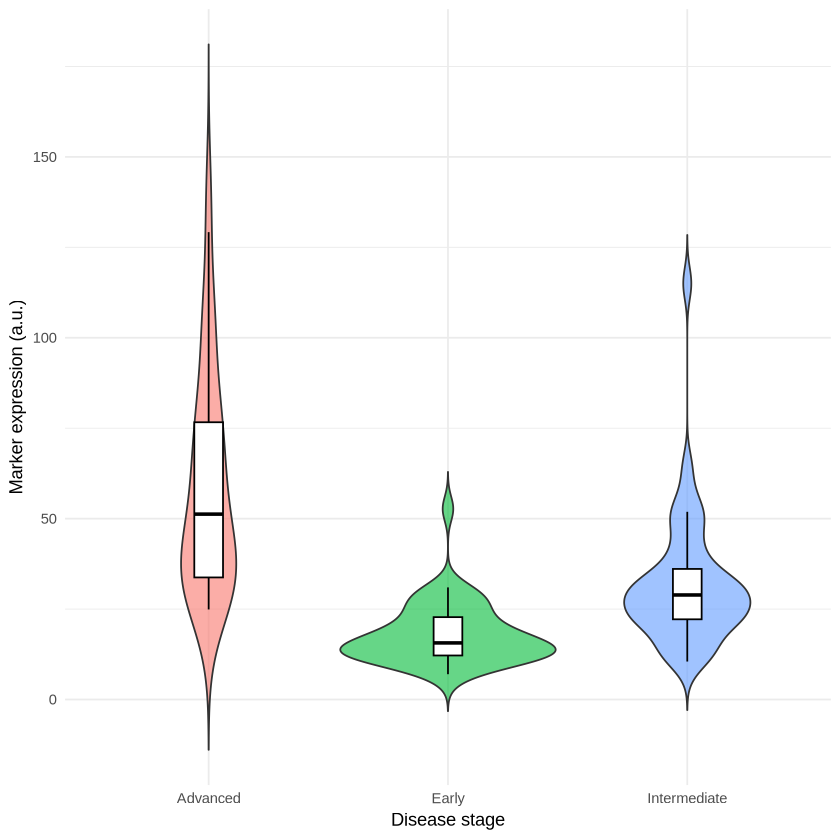

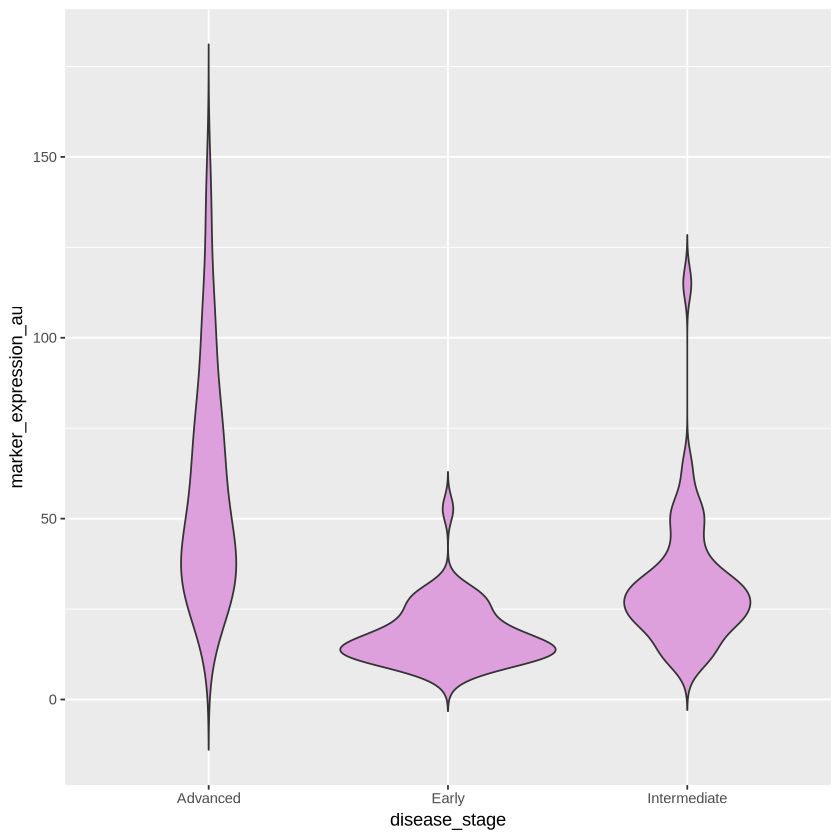

In [86]:

# VIOLIN PLOT: HOW DOES IT WORK?
#
# A violin plot compares the distributions of a numerical variable
# across categories. Here, each disease stage has its own violin.
#
# The y-axis shows marker expression. At each y value, a wider part
# of the violin means that more observations are concentrated nearby.
# The violin is a smoothed density curve mirrored on both sides.
#
# The shape shows where values are concentrated and whether the
# distribution is symmetric, skewed, or has several peaks.
# It does not show every individual observation.
#
# With scale = "width", all violins have the same maximum width.
# Their widths should therefore not be read as sample counts.
# The white lines mark Q1, the median, and Q3.
#
# In the next example, a narrow box plot is added on top of each violin.
# The violin shows the distribution's shape; the box shows its quartiles.

ggplot() +
  geom_violin(
    mapping = aes(
      x = disease_stage,          # Categories to compare
      y = marker_expression_au,   # Numerical values within each category
      fill = disease_stage        # Give each category its own fill color
    ),
    data = data,                  # Data used by this layer
    stat = "ydensity",            # Calculate a density for each category
    position = "dodge",           # Place different groups side by side
    trim = TRUE,                 # Stop each violin at the observed min and max
    bounds = c(0, Inf),          # Expression values cannot be below zero
    quantile.colour = "white",    # Color of quantile lines
    quantile.linetype = 1,       # Draw quantile lines; 0 would hide them
    quantile.linewidth = 0.5,    # Width of quantile lines
    scale = "width",             # Give all violins the same maximum width
    na.rm = FALSE,               # Remove missing values with a warning
    orientation = NA,            # Let ggplot2 determine the orientation
    show.legend = FALSE,         # Hide the redundant legend
    inherit.aes = TRUE,          # Also use mappings from ggplot()
    adjust = 1,                  # Degree of density smoothing
    quantiles = c(0.25, 0.5, 0.75), # Lines at Q1, median, and Q3
    color = "black",             # Outline color
    alpha = 0.7                  # Fill transparency
  ) +
  labs(
    x = "Disease stage",
    y = "Marker expression (a.u.)"
  )

ggplot(data, aes(x = disease_stage, y = marker_expression_au)) +
  geom_violin(
    aes(fill = disease_stage),
    trim = FALSE,
    alpha = 0.6,
    show.legend = FALSE
  ) +
  geom_boxplot(
    width = 0.12,          # Make the box narrow enough to fit inside the violin
    fill = "white",
    color = "black",
    outlier.shape = NA     # Hide outlier points; the violin still shows the distribution
  ) +
  labs(
    x = "Disease stage",
    y = "Marker expression (a.u.)"
  ) +
  theme_minimal()

# Extend the smoothed tails beyond the observed minimum and maximum.
ggplot(data, aes(x = disease_stage, y = marker_expression_au)) +
  geom_violin(trim = FALSE, fill = "plum")




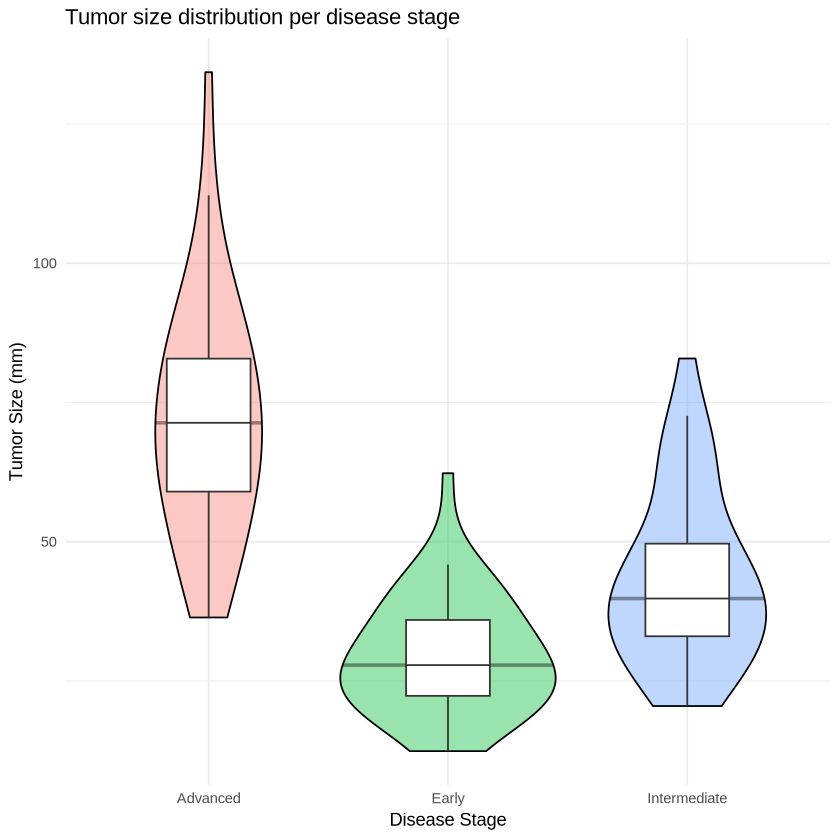

In [143]:
ggplot() + geom_violin(

    data = data,
    aes(y = tumor_size_mm, x = disease_stage, fill = disease_stage),
    show.legend = FALSE, alpha = 0.4, color = 'Black', adjust = 1.5, quantiles = c(0.5), quantile.colour = "black",
    quantile.linetype = 1, quantile.linewidth = 1) + theme_minimal() +


     geom_boxplot(data = data, aes(y = tumor_size_mm, x = disease_stage), width = 0.35, outlier.shape = NA, median.linewidth =  0.5) +
    labs(x = 'Disease Stage', y = 'Tumor Size (mm)', title = 'Tumor size distribution per disease stage')



   

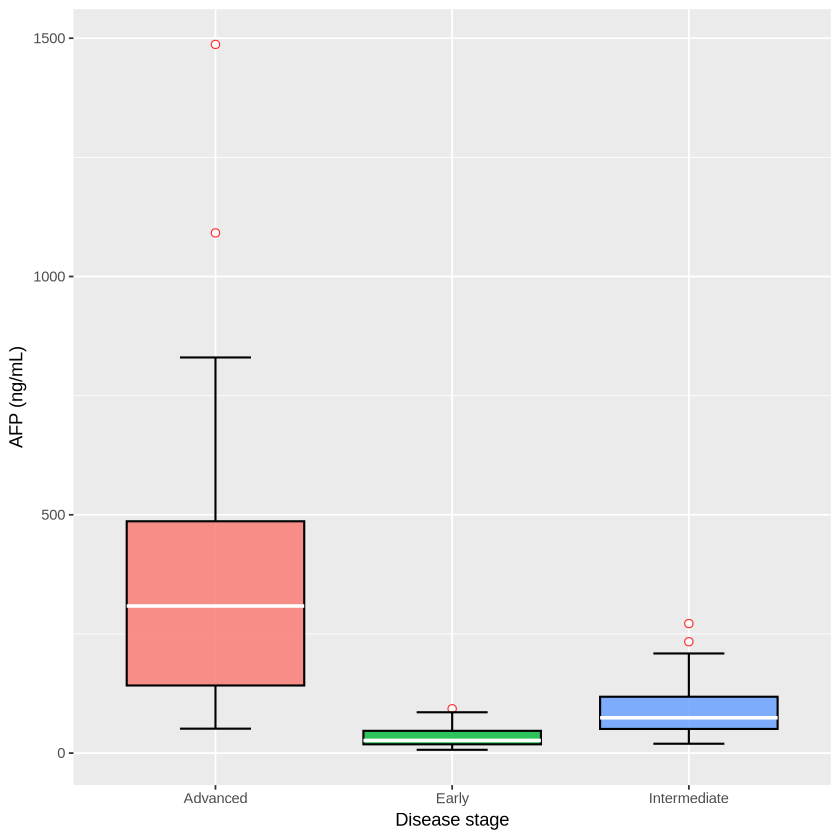

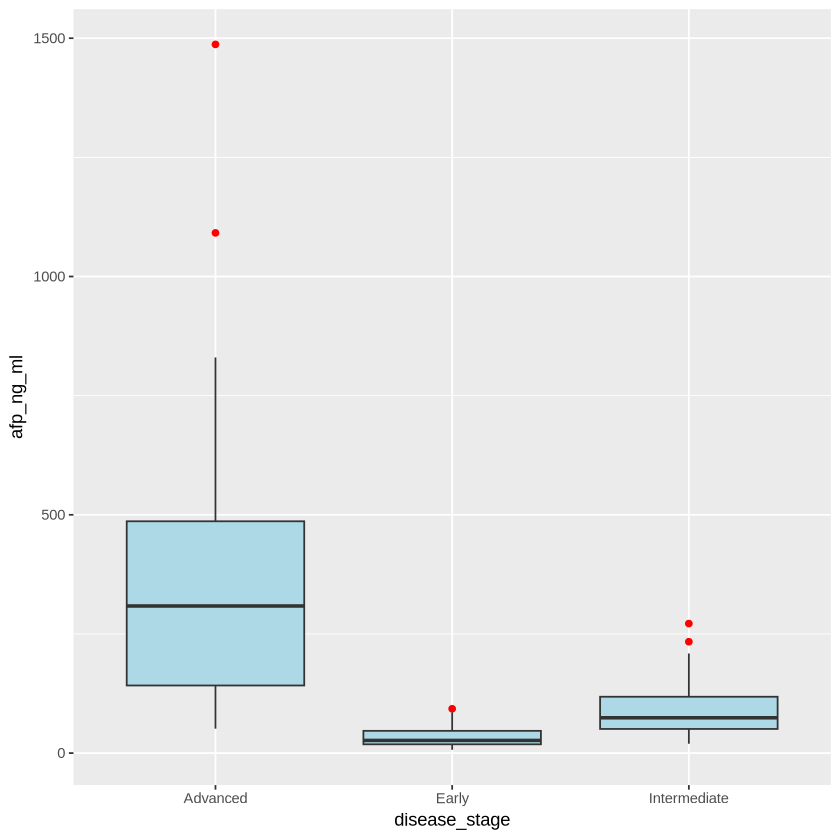

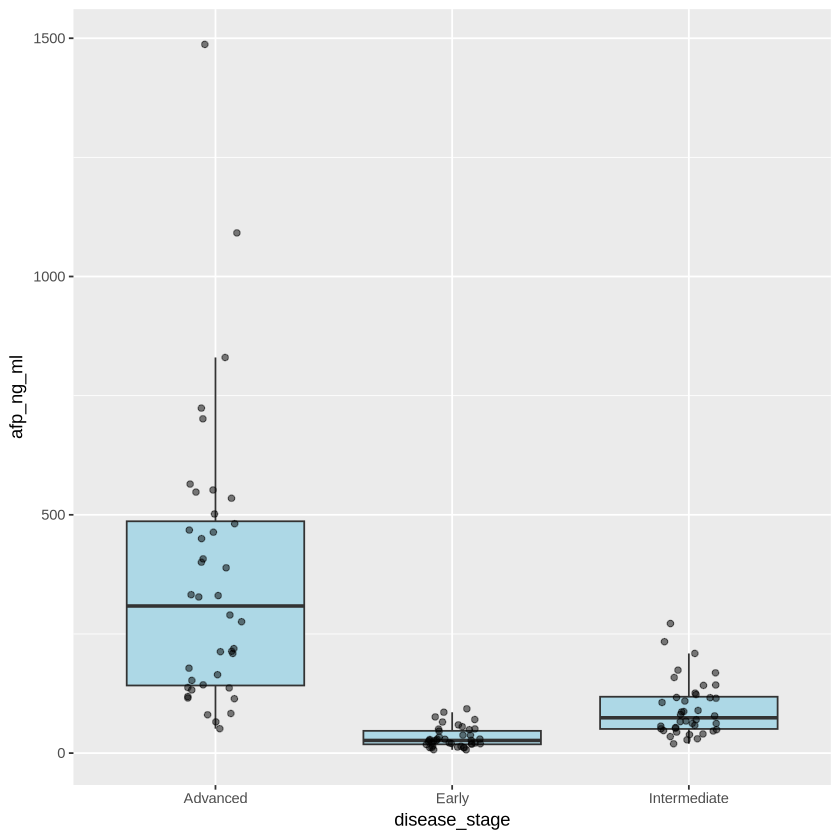

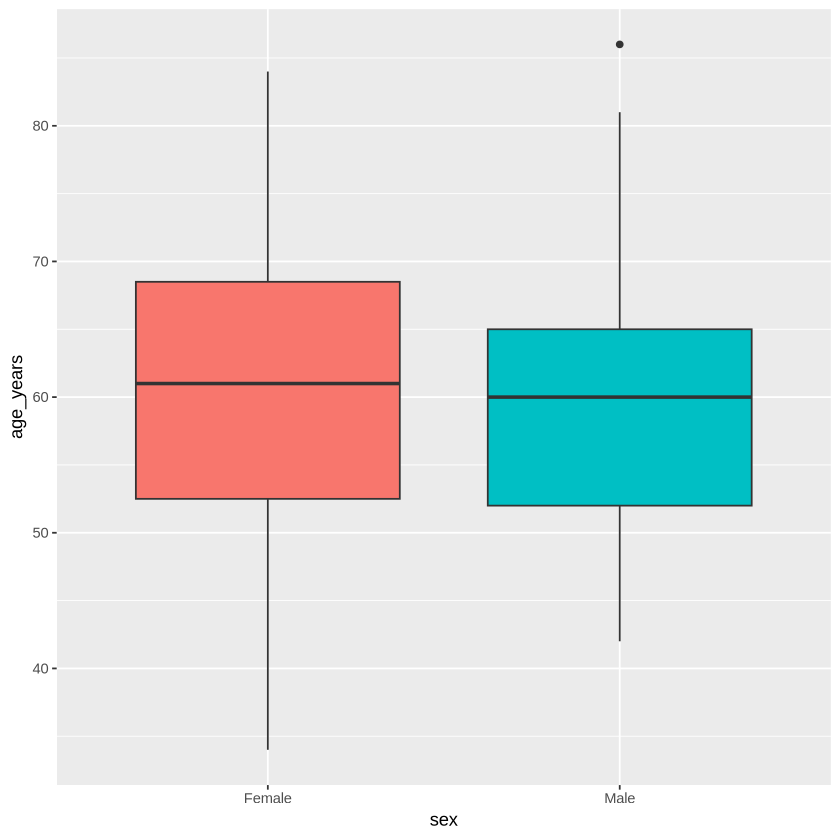

In [145]:
# BOX PLOT: HOW DOES IT WORK?
#
# A box plot summarizes a numerical distribution for each category.
# Here, we compare AFP values across disease stages.
#
# The line inside the box is the median.
# The bottom and top of the box are Q1 and Q3.
# The box therefore contains the middle 50% of the observations.
# The distance from Q1 to Q3 is called the interquartile range (IQR).
#
# By default, the whiskers extend to the most extreme observed values
# that are still within 1.5 × IQR of the box.
# They do not necessarily show the minimum and maximum.
# Values beyond the whiskers are displayed as individual points
# and are called outliers by this plotting rule.
#
# An outlier is not automatically a measurement error.
# A box plot gives a compact summary, but it does not show the full
# shape of the distribution as a violin plot does.

#?geom_boxplot

ggplot() +
  geom_boxplot(
    mapping = aes(
      x = disease_stage,          # Categories to compare
      y = afp_ng_ml,              # Numerical values within each category
      fill = disease_stage        # Color the boxes by stage
    ),
    data = data,                  # Data used by this layer
    stat = "boxplot",            # Calculate median, quartiles, and whiskers
    position = "dodge2",         # Separate boxes if several groups share a category
    
    outliers = TRUE,             # Display observations beyond the whiskers
    outlier.colour = "red",       # Color of outlier points
    outlier.fill = "white",       # Fill of outlier points with a fillable shape
    outlier.shape = 21,          # Point shape
    outlier.size = 2,            # Point size
    outlier.stroke = 0.5,        # Point border width
    outlier.alpha = 0.8,         # Point transparency
    
    whisker.colour = "black",     # Color of the whiskers
    whisker.linetype = 1,        # Solid whisker lines
    whisker.linewidth = 0.6,     # Whisker line width
    
    staple.colour = "black",      # Color of lines at the whisker ends
    staple.linetype = 1,         # Solid staple lines
    staple.linewidth = 0.6,      # Staple line width
    
    median.colour = "white",      # Color of the median line
    median.linetype = 1,         # Solid median line
    median.linewidth = 1,        # Median line width
    
    box.colour = "black",         # Color of the box outline
    box.linetype = 1,            # Solid box outline
    box.linewidth = 0.6,         # Box outline width
    
    notch = FALSE,              # Draw standard rectangular boxes
    notchwidth = 0.5,           # Notch width; matters when notch = TRUE
    staplewidth = 0.4,          # Make the lines at whisker ends visible
    varwidth = FALSE,           # Keep the boxes equally wide
    na.rm = FALSE,              # Remove missing values with a warning
    orientation = NA,           # Let ggplot2 determine the orientation
    show.legend = FALSE,        # Hide the redundant legend
    inherit.aes = TRUE,         # Also use mappings from ggplot()
    alpha = 0.8,                # Box transparency
    coef = 1.5                  # Whisker rule: 1.5 × IQR
  ) +
  labs(
    x = "Disease stage",
    y = "AFP (ng/mL)"
  )

# Highlight outliers.
ggplot(data, aes(x = disease_stage, y = afp_ng_ml)) +
  geom_boxplot(fill = "lightblue", outlier.colour = "red")


# Show all observations over the box plots.
ggplot(data, aes(x = disease_stage, y = afp_ng_ml)) +
  geom_boxplot(outlier.shape = NA, fill = "lightblue") +
  geom_jitter(width = 0.12, alpha = 0.5)


# Compare age by sex instead of AFP by stage.
ggplot(data, aes(x = sex, y = age_years, fill = sex)) +
  geom_boxplot(show.legend = FALSE)

In [ ]:
sample_id	sex	age_years	disease_stage	tumor_size_mm	afp_ng_ml	marker_expression_au

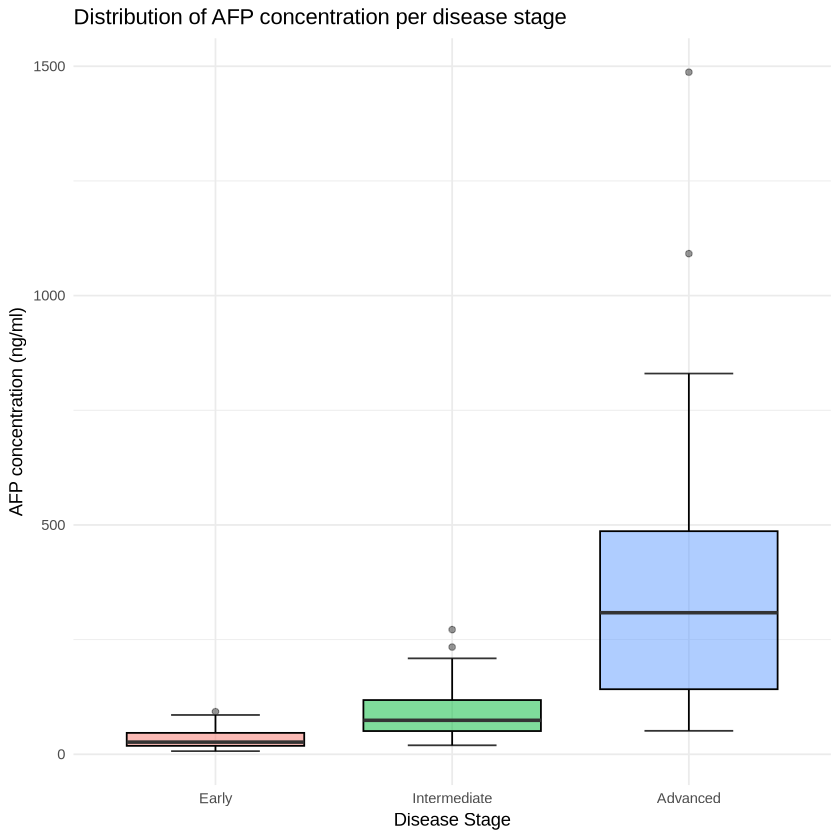

In [185]:
data$disease_stage <- factor(data$disease_stage, levels = c("Early", "Intermediate", "Advanced"))

ggplot() + geom_boxplot(
    data = data, aes(x = disease_stage, y = afp_ng_ml, fill = disease_stage),
    stat = 'boxplot', position = 'dodge2', alpha = 0.5, show.legend = FALSE,
    box.colour = 'black', box.linewidth = 0.5, coef = 1.5,
    whisker.colour = 'black', whisker.linewidth = 0.5, whisker.linetype = 1, staplewidth = 0.5) + theme_minimal() +
    labs(x = 'Disease Stage', y = 'AFP concentration (ng/ml)', title = 'Distribution of AFP concentration per disease stage')

In [ ]:
#Paper
# https://www.nature.com/articles/s41588-026-02692-x, 


#Will plot smth similar to plot 2C, rightmost boxplot




![Alt text](2C.png)

In [56]:
set.seed(42)

subtype_1 <- c(rnorm(100, mean = 0.53, sd = 0.03), c(0.66, 0.685, 0.69, 0.70, 0.74))
subtype_2 <- rnorm(100, mean = 0.66, sd = 0.05)
subtype_3 <- c(rnorm(100, mean = 0.60, sd = 0.05), 0.85)
subtype_4 <- c(rnorm(100, mean = 0.63, sd = 0.05), 0.76)

df <- data.frame(
  Subtype = factor(c(
    rep(1, length(subtype_1)),
    rep(2, length(subtype_2)),
    rep(3, length(subtype_3)),
    rep(4, length(subtype_4))
  )),
  Microbial_CRC_trait_score = c(subtype_1, subtype_2, subtype_3, subtype_4)
)  %>% slice_sample(prop = 1)

head(df,5)

,Subtype,Microbial_CRC_trait_score
,<fct>,<dbl>
1,2,0.6841597
2,1,0.4862236
3,4,0.5920540
4,1,0.5576219
5,3,0.6191923


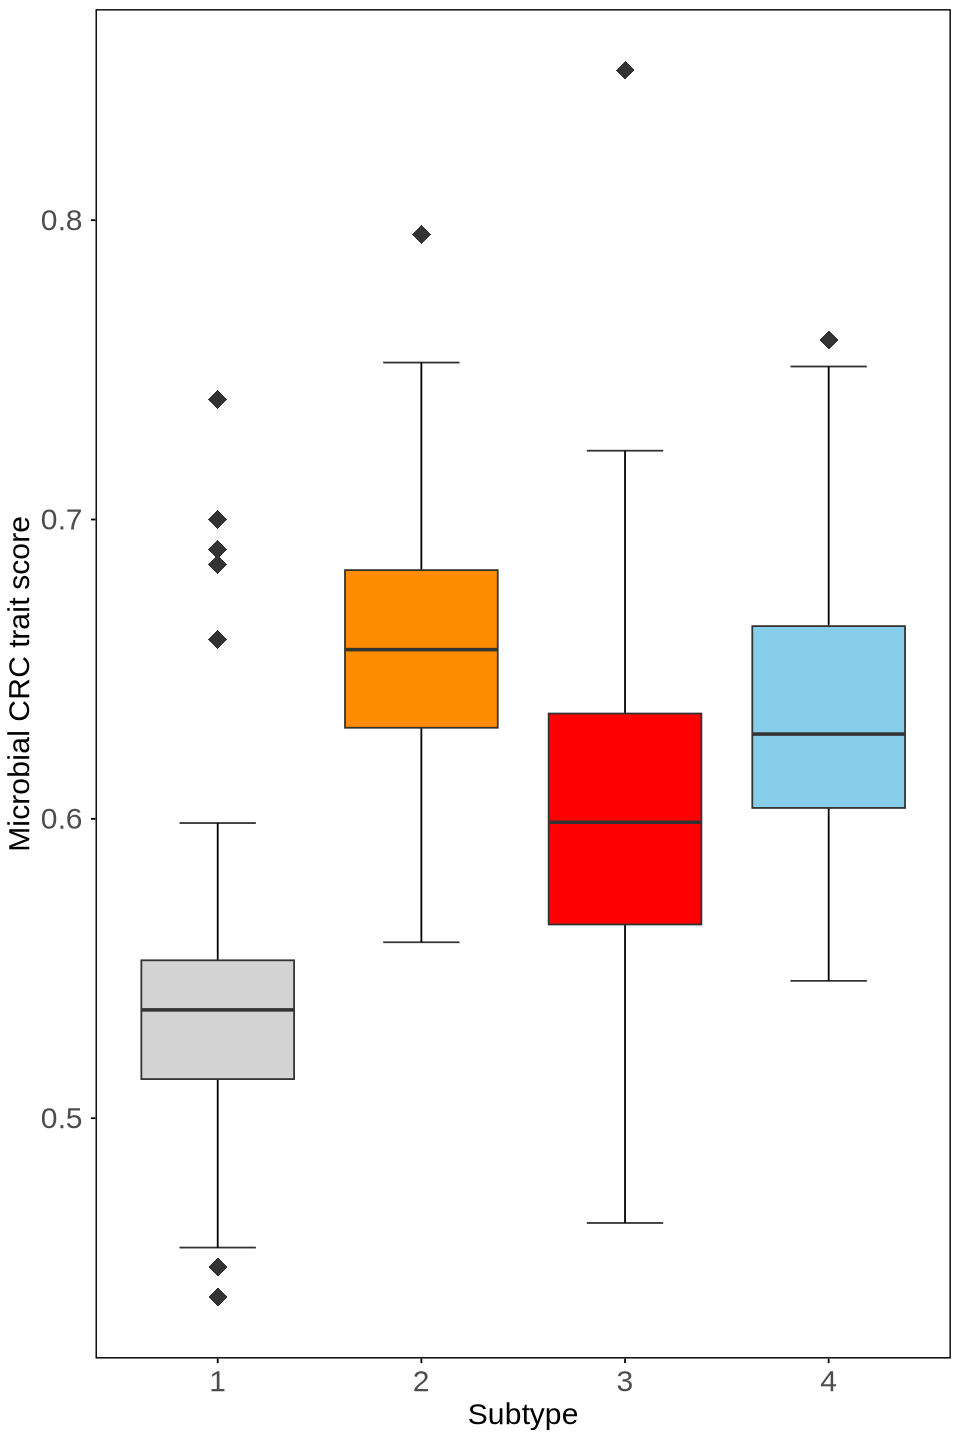

In [62]:
options(repr.plot.width = 8, repr.plot.height = 12)

ggplot() + geom_boxplot(data = df, aes(x = Subtype, y = Microbial_CRC_trait_score, fill = Subtype), show.legend = FALSE, whisker.colour = 'black', whisker.linewidth = 0.5, whisker.linetype = 1, staplewidth = 0.5, outlier.shape = 18,
                       outlier.size = 5) +



  geom_col() +   scale_fill_manual(values = c("1" = "#D3D3D3", "2" = "#FF8C00", "3" = "#FF0000", "4" = "#87CEEB")) + theme_minimal() +  


theme(
    panel.grid   = element_blank(),         
    panel.border = element_rect(color = "black", fill = NA, size = 0.8),
    axis.ticks   = element_line(color = "black"),
    axis.title.x = element_text(size = 18),
    axis.title.y = element_text(size = 18),
    axis.text.x = element_text(size = 18),
    axis.text.y = element_text(size = 18)


    
  ) + labs(x = 'Subtype', y = 'Microbial CRC trait score')

In [ ]:
#Data shows distribution of Microbial CRC trait score (continuous numberic variable, assume its normaly distributed) for 4 subtypes (factors, [1-4]). 
#Boxplot is appropriate visualize this data, CRC trait score is distributed normally-ish, so calculation of medians, IQR and outliers will be highly informative.
#CRC trait score statistics are distibuted to 4 subtypes, making it natural to build  separate boxplots for each of them, searching for possible associations between subtype and score

In [75]:
#Calculating mean, median, mode, sd, variance, Q1,Q2,Q3,IQR for CRC_trait_score variable
var <- df$Microbial_CRC_trait_score

get_mode <- function(x, na.rm = FALSE) {
  if (na.rm) x <- x[!is.na(x)]
  ux <- unique(x)
  ux[which.max(tabulate(match(x, ux)))]
}

mean_value     <- mean(var)
median_value   <- median(var)
mode_value     <- get_mode(var)
sd_value       <- sd(var)
variance_value <- sd_value ** 2

Q1 <- as.numeric(quantile(var, probs = 0.25))
Q2 <- as.numeric(quantile(var, probs = 0.50))
Q3 <- as.numeric(quantile(var, probs = 0.75))

iqr_value <- IQR(var, na.rm = TRUE)

# 5. Build the summary table
df_summary <- t(data.frame(list(
  'Mean' = mean_value,
  'Median' = median_value,
  'Mode' = mode_value,
  'SD' = sd_value,
  'Variance' = variance_value,
  'Q1' = Q1,
  'Q2' = Q2,
  'Q3' = Q3,
  'IQR' = iqr_value
)))

df_summary

Mean,0.606530632
Median,0.607330124
Mode,0.684159693
SD,0.065658332
Variance,0.004311017
Q1,0.552813156
Q2,0.607330124
Q3,0.655306035
IQR,0.102492879
